In [9]:
using Revise
using MajoranaPropagation
using PauliPropagation

using Plots

Simulate the dynamics of the spinful Hubbard model on a 2D lattice of $N_x \times N_y$ spinful sites. The Hamiltonian is
$$\hat{H}=-t \sum_{\langle i,j\rangle, \sigma=\{\uparrow, \downarrow\}}\left(\hat{c}_{i, \sigma}^{\dagger} \hat{c}_{j, \sigma}+\hat{c}_{j, \sigma}^{\dagger} \hat{c}_{i, \sigma}\right)+U \sum_i \hat{n}_{i \uparrow} \hat{n}_{i \downarrow}$$

In [10]:
N_x = 4
N_y = 4
N_spinful_sites = N_x * N_y
t = 1.
U = 2.

n_layers = 12
dt = 0.07

0.07

Get 1D connectivity, and create the circtuit for implementing a single layer of first order Trotterization.

In [11]:
topo = rectangletopology(N_x, N_y)

circ_single = []
thetas_single = []

#up hoppings 
for (i, j) in topo
    push!(circ_single, FermionicGate(:hopup, [i, j]))
    push!(thetas_single, -t * dt)
end

#down hoppings 
for (i, j) in topo
    push!(circ_single, FermionicGate(:hopdn, [i, j]))
    push!(thetas_single, -t * dt)
end

#on-site repulsion 
for i = 1:N_spinful_sites
    push!(circ_single, FermionicGate(:nupndn, i))
    push!(thetas_single, U * dt)
end

#### Set the truncations
1. `min_abs_coeff`: PP coefficient truncation
2. `max_unpaired`: number of unpaired Majoranas, namely the number of indices $i$ where only one of $\gamma_i$, $\gamma'_i$ are non-zero

In [12]:
min_abs_coeff = 1.e-5
max_unpaired = 6
unpaired_mask = create_unpaired_mask(2 * N_spinful_sites)

0xaaaaaaaaaaaaaaaa

Set the inital state as the checkerboard state $\ket{\uparrow\downarrow\cdots\uparrow\downarrow}$

In [13]:
#initial state 
initial_state_label = "Checkerboard"
fock_state = FockState(N_spinful_sites, :checkerboard, true; nx=N_x)

fock_state

Fock state with 16 fermions at positions
    ↑: 1, 3, 6, 8, 9, 11, 14, 16
    ↓: 2, 4, 5, 7, 10, 12, 13, 15


Backpropagate $n_{2,\uparrow}$, the up density on site 2

In [14]:
site_index = 3
obs = MajoranaSum(N_spinful_sites, :nupndn, site_index)

@show obs 

res = zeros(n_layers+1)
res[1] = overlapwithfock(obs, fock_state)
length_res = zeros(n_layers+1)
length_res[1] = length(obs)

for k=1:n_layers
    propagate!(circ_single, obs, thetas_single, min_abs_coeff=min_abs_coeff, max_unpaired=max_unpaired, unpaired_mask=unpaired_mask)
    res[k+1] = overlapwithfock(obs, fock_state)
    length_res[k+1] = length(obs)
end 

obs = MajoranaSum with 4 terms:
    0.25 * 0000000000000000000000000000000000000000000000000000000000000000
    0.25 * 0000000011000000000000000000000000000000000000000000000000000000
    -0.25 * 0000000011110000000000000000000000000000000000000000000000000000
    0.25 * 0000000000110000000000000000000000000000000000000000000000000000


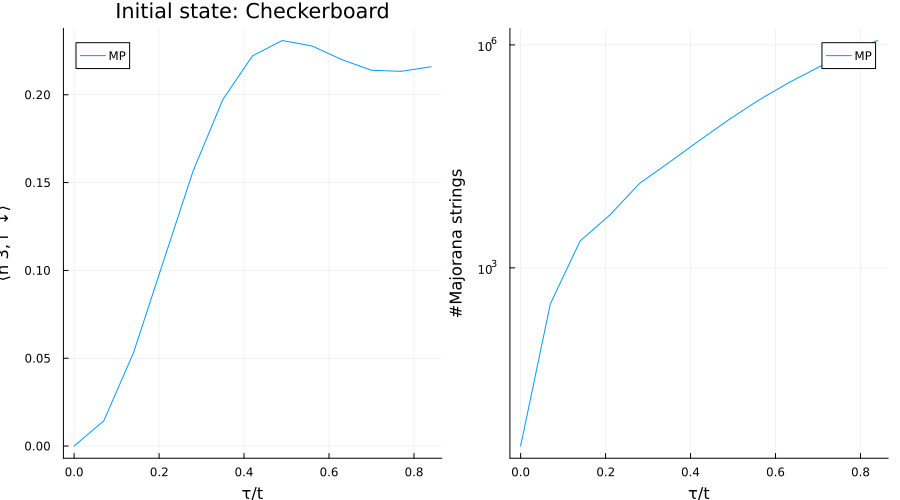

In [15]:
p_res = plot(dt*(0:n_layers)./ t, res, label="MP", xlabel="τ/t", ylabel="⟨n $site_index,↑ ↓⟩", title = "Initial state: " * initial_state_label)
p_length = plot(dt*(0:n_layers)./ t, length_res, label="MP", xlabel="τ/t", ylabel="#Majorana strings", yscale=:log10)    

plot(p_res, p_length, layout=(1,2), size=(900,500))